<h1 style="
  font-size: 55px; 
  text-align: center; 
  font-family: 'Poppins', sans-serif; 
  text-shadow: 2px 2px 5px rgba(70, 145, 196, 0.84);
  letter-spacing: 2px;
">
  <b>📊 Data Visualization</b>
</h1>
<hr style="width: 60%; border: 2px solid rgba(25, 58, 80, 0.85); border-radius: 5px;">


#### **=> Ossama Ayman**
---

<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 600;
  letter-spacing: 0.5px;
">
  <b>Import Libraries</b>?
</h4>


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('cleaned_merged_data.csv')
df.head()

,TARGET,NAME_CONTRACT_TYPE_x,CODE_GENDER,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,...,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,NAME_CLIENT_TYPE,NAME_PORTFOLIO,CHANNEL_TYPE,CNT_PAYMENT,NAME_YIELD_GROUP,LOAN_ACTIVITY_SCORE,RATIO_AMT_CREDIT
0,1,Cash loans,M,202500.0,Working,Secondary / secondary special,Single / not married,House/apartment,Labor,1.0,...,Approved,606,Cash through the bank,New,POS,Stone,24.0,Middle,2,0.440373
1,0,Cash loans,F,270000.0,Others,Higher education,Married,House/apartment,Admin,2.0,...,Approved,746,Cash through the bank,Repeater,Cash,Credit and cash offices,12.0,Low,2,0.800834
2,0,Cash loans,F,270000.0,Others,Higher education,Married,House/apartment,Admin,2.0,...,Approved,828,Cash through the bank,Refreshed,POS,Stone,6.0,High,2,0.269530
3,0,Cash loans,F,270000.0,Others,Higher education,Married,House/apartment,Admin,2.0,...,Approved,2341,Cash through the bank,Refreshed,POS,Country-wide,12.0,High,2,0.052612
4,0,Revolving loans,M,67500.0,Working,Secondary / secondary special,Single / not married,House/apartment,Labor,1.0,...,Approved,815,Cash through the bank,New,POS,Regional / Local,4.0,High,2,0.148932


<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 900;
  letter-spacing: 0.5px;
">
  <b>Q21: Do clients with a higher internal loan activity score get approved faster?
</b>
</h4>


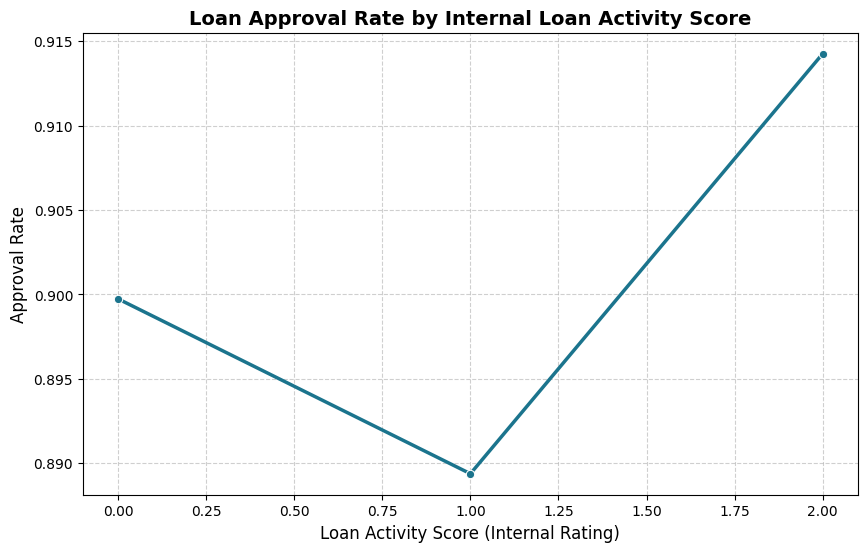

In [3]:
loan_score_approval = df.groupby('LOAN_ACTIVITY_SCORE')['TARGET'].apply(lambda x: 1 - x.mean()).reset_index()
loan_score_approval.columns = ['LOAN_ACTIVITY_SCORE', 'Approval Rate']

plt.figure(figsize=(10,6))
sns.lineplot(
    x='LOAN_ACTIVITY_SCORE',
    y='Approval Rate',
    data=loan_score_approval,
    marker='o',
    color='#1b748d',
    linewidth=2.5
)

plt.title('Loan Approval Rate by Internal Loan Activity Score', fontsize=14, fontweight='bold')
plt.xlabel('Loan Activity Score (Internal Rating)', fontsize=12)
plt.ylabel('Approval Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 900;
  letter-spacing: 0.5px;
">
  <b>Q22: 
How does the customer's income relate to their credit ratio, and does this relationship differ between defaulters and non-defaulters?
</b>
</h4>


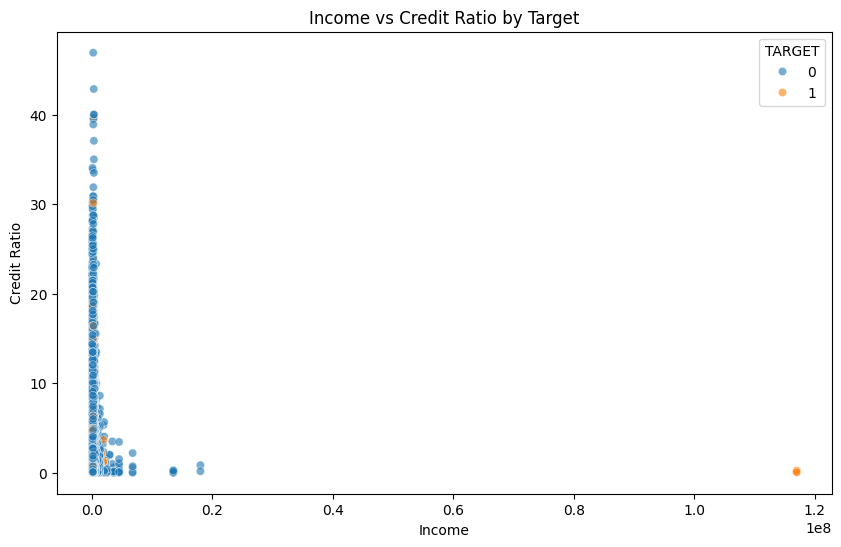

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    y="RATIO_AMT_CREDIT",
    hue="TARGET",
    alpha=0.6
)
plt.title("Income vs Credit Ratio by Target")
plt.xlabel("Income")
plt.ylabel("Credit Ratio")
plt.show()


<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 900;
  letter-spacing: 0.5px;
">
  <b>Q23: 
Is there a noticeable difference in the number of payments between customers who default and those who do not?</b>
</h4>


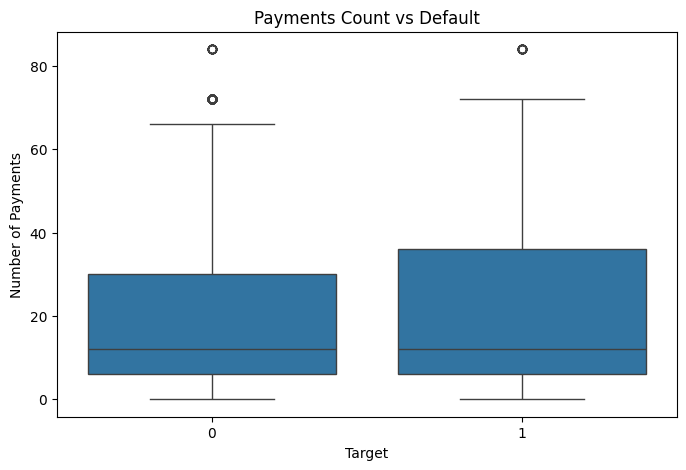

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="TARGET",
    y="CNT_PAYMENT"
)
plt.title("Payments Count vs Default")
plt.xlabel("Target")
plt.ylabel("Number of Payments")
plt.show()


<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 900;
  letter-spacing: 0.5px;
">
  <b>Q24: 
How is the distribution of loan activity scores different between defaulters and non-defaulters?</b>
</h4>


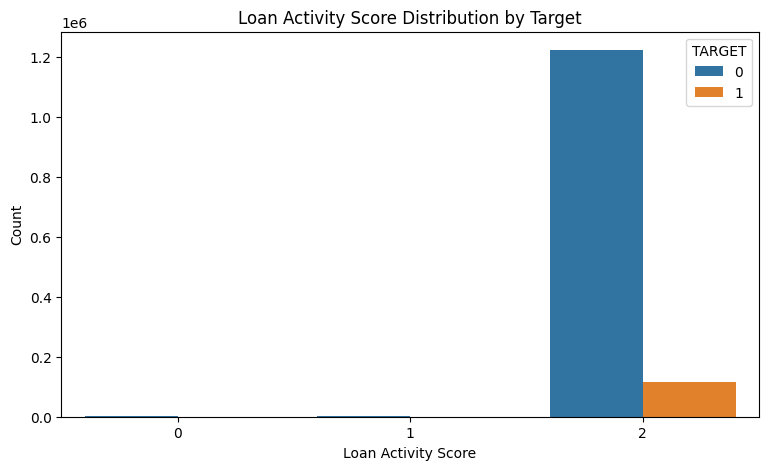

In [7]:
plt.figure(figsize=(9,5))
sns.countplot(
    data=df,
    x="LOAN_ACTIVITY_SCORE",
    hue="TARGET"
)
plt.title("Loan Activity Score Distribution by Target")
plt.xlabel("Loan Activity Score")
plt.ylabel("Count")
plt.show()


<h4 style="
  color: rgba(53, 170, 206, 0.84);
  font-family: 'Poppins', sans-serif;
  font-weight: 900;
  letter-spacing: 0.5px;
">
  <b>Q25: 
Do housing type and family status affect the likelihood of loan default?</b>
</h4>


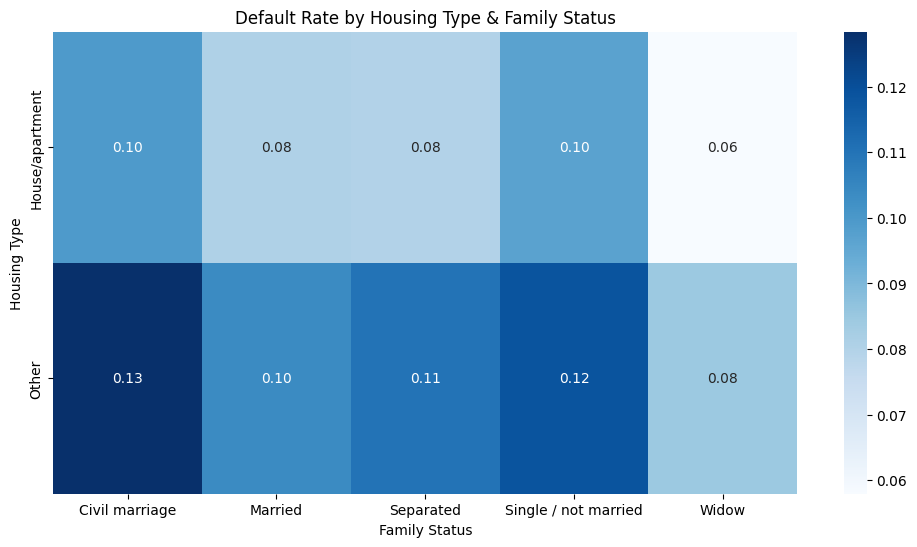

In [6]:
pivot = df.pivot_table(
    index="NAME_HOUSING_TYPE",
    columns="NAME_FAMILY_STATUS",
    values="TARGET",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Default Rate by Housing Type & Family Status")
plt.xlabel("Family Status")
plt.ylabel("Housing Type")
plt.show()
